In [2]:
import os, sys, json, time, math, warnings
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 1234
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.family": "serif",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

os.makedirs("runs", exist_ok=True)
os.makedirs("figs", exist_ok=True)

print(f"torch  {torch.__version__}")
print(f"device {DEVICE}")
if DEVICE == "cuda":
    print(f"gpu    {torch.cuda.get_device_name(0)}")

torch  2.11.0+cu128
device cuda
gpu    Tesla T4


In [4]:
import burgers2d_common as B
import torch.nn as nn


class PINN2D(nn.Module):
    """Fully-connected PINN: (x, y, t) -> (u, v).

    Stores the last hidden-layer activations when `capture=True`,
    used later for the interpretability figure.
    """

    def __init__(self, width=64, depth=5, in_dim=3, out_dim=2):
        super().__init__()
        layers, d = [], in_dim
        for _ in range(depth):
            layers += [nn.Linear(d, width), nn.Tanh()]
            d = width
        layers += [nn.Linear(d, out_dim)]
        self.net = nn.Sequential(*layers)
        self.width, self.depth = width, depth
        self.capture = False
        self._last_hidden = None
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, z):
        if not self.capture:
            return self.net(z)
        h = z
        for layer in self.net[:-1]:
            h = layer(h)
        self._last_hidden = h.detach()
        return self.net[-1](h)

    @torch.no_grad()
    def hidden_at(self, z):
        """Return last-hidden-layer activations for input batch z."""
        prev, self.capture = self.capture, True
        _ = self.forward(z)
        self.capture = prev
        return self._last_hidden

In [5]:
import burgers2d_common as B


def _analytic_residual_check(nu=B.NU_DEFAULT, n=64, device=DEVICE):
    """Finite-difference check that exact_uv satisfies 2D Burgers."""
    h, dt = 1e-4, 1e-4
    x = torch.rand(n, 1, device=device) * 0.8 + 0.1
    y = torch.rand(n, 1, device=device) * 0.8 + 0.1
    t = torch.rand(n, 1, device=device) * 0.8 + 0.1

    def U(a, b, c):
        return B.exact_uv(a, b, c, nu)

    u, v = U(x, y, t)
    ux = (U(x + h, y, t)[0] - U(x - h, y, t)[0]) / (2 * h)
    uy = (U(x, y + h, t)[0] - U(x, y - h, t)[0]) / (2 * h)
    ut = (U(x, y, t + dt)[0] - U(x, y, t - dt)[0]) / (2 * dt)
    uxx = (U(x + h, y, t)[0] - 2 * u + U(x - h, y, t)[0]) / h**2
    uyy = (U(x, y + h, t)[0] - 2 * u + U(x, y - h, t)[0]) / h**2

    r_u = ut + u * ux + v * uy - nu * (uxx + uyy)
    return r_u.abs().max().item()


print(f"max |r_u| on analytic solution: {_analytic_residual_check():.3e}")

max |r_u| on analytic solution: 2.369e-01


In [7]:
import importlib
import burgers2d_common as B
import train2d
importlib.reload(B); importlib.reload(train2d)

pinn = PINN2D(width=64, depth=5)
hist_pinn, dir_pinn = train2d.train_pinn2d(
    pinn, iters=20000, n_r=8000, n_i=1000, n_b=500,
    lam_r=1.0, lam_i=10.0, lam_b=10.0,
    lr=1e-3, resample_every=2000, device=DEVICE,
    tag="pinn2d_w64d5", seed=SEED,
    extra_meta={"model": "PINN2D", "width": 64, "depth": 5},
)

pinn = train2d.lbfgs_polish(pinn, iters=500, device=DEVICE, seed=SEED)
ru, rv = train2d._val_errors(pinn, B.NU_DEFAULT, DEVICE)
print(f"after L-BFGS: rel_u={ru:.3e}  rel_v={rv:.3e}")
torch.save({"state_dict": pinn.state_dict()}, f"{dir_pinn}/polished.pt")

     0  L=3.077e+01  r=5.479e-02 ic=1.374e+00 bc=1.698e+00 | relL2 u=9.477e-01 v=9.378e-01 | 0s
   500  L=2.875e-02  r=3.354e-03 ic=1.388e-03 bc=1.151e-03 | relL2 u=4.507e-02 v=2.898e-02 | 15s
  1000  L=2.604e-03  r=1.058e-03 ic=7.934e-05 bc=7.532e-05 | relL2 u=1.174e-02 v=7.446e-03 | 30s
  1500  L=8.351e-04  r=4.789e-04 ic=1.535e-05 bc=2.028e-05 | relL2 u=5.292e-03 v=3.577e-03 | 48s
  2000  L=3.801e-04  r=2.311e-04 ic=6.328e-06 bc=8.567e-06 | relL2 u=3.138e-03 v=2.471e-03 | 62s
  2500  L=1.710e-04  r=1.061e-04 ic=2.994e-06 bc=3.498e-06 | relL2 u=1.822e-03 v=1.751e-03 | 77s
  3000  L=9.279e-05  r=5.694e-05 ic=1.767e-06 bc=1.818e-06 | relL2 u=1.296e-03 v=1.321e-03 | 93s
  3500  L=7.416e-05  r=4.226e-05 ic=1.648e-06 bc=1.542e-06 | relL2 u=1.936e-03 v=1.618e-03 | 109s
  4000  L=4.998e-05  r=3.187e-05 ic=9.517e-07 bc=8.588e-07 | relL2 u=1.044e-03 v=8.511e-04 | 125s
  4500  L=3.708e-05  r=2.376e-05 ic=7.022e-07 bc=6.302e-07 | relL2 u=9.644e-04 v=7.115e-04 | 140s
  5000  L=3.245e-05  r=1.929

In [13]:
torch.set_num_threads(2)

In [17]:
# Cell 8 — verify double-backward through the quantum layer
import importlib, qpinn2d
importlib.reload(qpinn2d)

_q = qpinn2d.QPINN2D(n_qubits=4, n_layers=4).to(DEVICE)
_x = torch.rand(16, 1, device=DEVICE)
_y = torch.rand(16, 1, device=DEVICE)
_t = torch.rand(16, 1, device=DEVICE)

_ru, _rv = B.pde_residual(_q, _x, _y, _t)
_loss = (_ru**2).mean() + (_rv**2).mean()
_loss.backward()

qg = _q.q_weights.grad
print(f"residual finite      : {torch.isfinite(_ru).all().item()}")
print(f"q_weights grad exists: {qg is not None}")
print(f"q_weights grad norm  : {qg.norm().item():.4e}")
assert qg is not None and qg.norm().item() > 0, \
    "Quantum gradients are dead — check diff_method / device consistency."
print("PASS: second-order gradients flow through the PQC.")

residual finite      : True
q_weights grad exists: True
q_weights grad norm  : 4.3662e-01
PASS: second-order gradients flow through the PQC.


In [18]:
# Cell 9 — QPINN training
torch.set_num_threads(2)

qpinn = qpinn2d.QPINN2D(n_qubits=4, n_layers=3, enc_width=32,
                        head_width=32, reupload=True)
w_init_snapshot = qpinn.q_weights.detach().clone()   # for Cell 17b

n_par = sum(p.numel() for p in qpinn.parameters())
n_q = qpinn.q_weights.numel()
print(f"QPINN params: {n_par} total ({n_q} quantum, {n_par - n_q} classical)")

hist_qpinn, dir_qpinn = train2d.train_pinn2d(
    qpinn, iters=3000, n_r=256, n_i=128, n_b=32,
    lam_r=1.0, lam_i=10.0, lam_b=10.0,
    lr=3e-3, resample_every=250, device=DEVICE,
    log_every=25, val_every=250,
    tag="qpinn2d_q4l3", seed=SEED,
    extra_meta={"model": "QPINN2D", "n_qubits": 4, "n_layers": 3,
                "reupload": True, "n_quantum_params": n_q},
)

QPINN params: 2634 total (36 quantum, 2598 classical)
     0  L=7.139e+01  r=9.191e-01 ic=4.132e+00 bc=2.914e+00 | relL2 u=1.517e+00 v=8.934e-01 | 1s
   250  L=2.552e-02  r=9.847e-03 ic=5.870e-04 bc=9.798e-04 | relL2 u=3.136e-02 v=2.097e-02 | 236s
   500  L=1.597e-02  r=6.977e-03 ic=4.170e-04 bc=4.818e-04 | relL2 u=2.286e-02 v=1.487e-02 | 471s
   750  L=1.049e-02  r=4.027e-03 ic=3.066e-04 bc=3.396e-04 | relL2 u=2.077e-02 v=1.218e-02 | 708s
  1000  L=7.801e-03  r=3.409e-03 ic=2.156e-04 bc=2.237e-04 | relL2 u=1.738e-02 v=9.784e-03 | 943s
  1250  L=5.813e-03  r=2.634e-03 ic=1.488e-04 bc=1.691e-04 | relL2 u=1.476e-02 v=8.241e-03 | 1176s
  1500  L=4.891e-03  r=2.234e-03 ic=1.193e-04 bc=1.463e-04 | relL2 u=1.375e-02 v=7.268e-03 | 1411s
  1750  L=4.321e-03  r=2.086e-03 ic=9.884e-05 bc=1.247e-04 | relL2 u=1.285e-02 v=6.754e-03 | 1646s
  2000  L=4.064e-03  r=2.120e-03 ic=8.644e-05 bc=1.079e-04 | relL2 u=1.216e-02 v=6.217e-03 | 1879s
  2250  L=3.825e-03  r=2.004e-03 ic=8.323e-05 bc=9.884e-05 | r

### **Finite Difference**

In [20]:
# Cell 10b — run FDM
import importlib, solver_fdm
importlib.reload(solver_fdm)

t0 = time.time()
x_fdm, y_fdm, snaps_fdm = solver_fdm.solve_fdm(nx=101, ny=101, t_end=1.0)
wall_fdm = time.time() - t0

Xg, Yg = np.meshgrid(x_fdm, y_fdm, indexing="ij")
for tt in sorted(snaps_fdm):
    ue, ve = B.exact_uv(Xg, Yg, np.full_like(Xg, tt))
    uu, vv = snaps_fdm[tt]
    print(f"t={tt:.2f}  rel_u={B.rel_l2(uu, ue):.3e}  rel_v={B.rel_l2(vv, ve):.3e}")
print(f"FDM wall: {wall_fdm:.1f}s")

t=0.00  rel_u=0.000e+00  rel_v=0.000e+00
t=0.25  rel_u=3.810e-03  rel_v=2.641e-03
t=0.50  rel_u=5.818e-03  rel_v=3.888e-03
t=0.75  rel_u=6.763e-03  rel_v=4.363e-03
t=1.00  rel_u=7.002e-03  rel_v=4.368e-03
FDM wall: 1.5s


### **Fourier Spectral Solver**

In [22]:
# Cell 11b — run spectral
import solver_spectral
importlib.reload(solver_spectral)

t0 = time.time()
x_sp, y_sp, snaps_sp = solver_spectral.solve_spectral(n=128, dt=2e-4)
wall_sp = time.time() - t0

Xs, Ys = np.meshgrid(x_sp, y_sp, indexing="ij")
for tt in sorted(snaps_sp):
    ue, ve = B.exact_uv(Xs, Ys, np.full_like(Xs, tt))
    uu, vv = snaps_sp[tt]
    print(f"t={tt:.2f}  rel_u={B.rel_l2(uu, ue):.3e}  rel_v={B.rel_l2(vv, ve):.3e}")
print(f"Spectral wall: {wall_sp:.1f}s")

t=0.00  rel_u=0.000e+00  rel_v=0.000e+00
t=0.25  rel_u=6.418e-02  rel_v=4.447e-02
t=0.50  rel_u=8.024e-02  rel_v=5.359e-02
t=0.75  rel_u=9.008e-02  rel_v=5.806e-02
t=1.00  rel_u=9.475e-02  rel_v=5.903e-02
Spectral wall: 129.1s


### **Glerkin Finite Element Method**

In [24]:
# Cell 12b — run FEM
import solver_fem
importlib.reload(solver_fem)

t0 = time.time()
x_fem, y_fem, snaps_fem = solver_fem.solve_fem(nx=81, ny=81)
wall_fem = time.time() - t0

Xf, Yf = np.meshgrid(x_fem, y_fem, indexing="ij")
for tt in sorted(snaps_fem):
    ue, ve = B.exact_uv(Xf, Yf, np.full_like(Xf, tt))
    uu, vv = snaps_fem[tt]
    print(f"t={tt:.2f}  rel_u={B.rel_l2(uu, ue):.3e}  rel_v={B.rel_l2(vv, ve):.3e}")
print(f"FEM wall: {wall_fem:.1f}s")

t=0.00  rel_u=0.000e+00  rel_v=0.000e+00
t=0.25  rel_u=1.590e-04  rel_v=1.102e-04
t=0.50  rel_u=1.827e-04  rel_v=1.221e-04
t=0.75  rel_u=2.056e-04  rel_v=1.327e-04
t=1.00  rel_u=3.078e-04  rel_v=1.921e-04
FEM wall: 1.1s


### **Unified Evaluation on Common Grid**

In [25]:
# Cell 13 — resample everything to a common grid
from scipy.interpolate import RegularGridInterpolator

T_EVAL = (0.0, 0.25, 0.5, 0.75, 1.0)
N_REF = 101
x_ref = np.linspace(0.0, 1.0, N_REF)
y_ref = np.linspace(0.0, 1.0, N_REF)
Xr, Yr = np.meshgrid(x_ref, y_ref, indexing="ij")


def to_ref(x_src, y_src, field):
    """Bilinear interpolation of a solver field onto the reference grid."""
    f = RegularGridInterpolator((x_src, y_src), field,
                                bounds_error=False, fill_value=None)
    pts = np.stack([Xr.ravel(), Yr.ravel()], axis=-1)
    return f(pts).reshape(N_REF, N_REF)


@torch.no_grad()
def model_on_ref(model, t_eval, device=DEVICE, chunk=20000):
    """Evaluate a PINN/QPINN on the reference grid in chunks.

    Chunking keeps the QPINN statevector batch within VRAM; a full
    101x101 batch through a 4-qubit circuit is fine, but the same code
    path must survive larger n_qubits without OOM.
    """
    pts = np.stack([Xr.ravel(), Yr.ravel(),
                    np.full(Xr.size, float(t_eval))], axis=-1)
    inp = torch.tensor(pts, dtype=torch.float32, device=device)
    outs = []
    for i in range(0, inp.shape[0], chunk):
        outs.append(model(inp[i:i + chunk]).cpu())
    out = torch.cat(outs, dim=0).numpy()
    return out[:, 0].reshape(N_REF, N_REF), out[:, 1].reshape(N_REF, N_REF)


# Assemble the master results dictionary: RESULTS[method][t] = (u, v)
RESULTS = {m: {} for m in
           ["Exact", "FDM", "Spectral", "FEM", "PINN", "QPINN"]}

for tt in T_EVAL:
    ue, ve = B.exact_uv(Xr, Yr, np.full_like(Xr, tt))
    RESULTS["Exact"][tt] = (ue, ve)

    uu, vv = snaps_fdm[tt]
    RESULTS["FDM"][tt] = (to_ref(x_fdm, y_fdm, uu), to_ref(x_fdm, y_fdm, vv))

    uu, vv = snaps_sp[tt]
    RESULTS["Spectral"][tt] = (to_ref(x_sp, y_sp, uu), to_ref(x_sp, y_sp, vv))

    uu, vv = snaps_fem[tt]
    RESULTS["FEM"][tt] = (to_ref(x_fem, y_fem, uu), to_ref(x_fem, y_fem, vv))

    RESULTS["PINN"][tt] = model_on_ref(pinn, tt)
    RESULTS["QPINN"][tt] = model_on_ref(qpinn, tt)

# Error table
ERR = {m: {"u": [], "v": []} for m in RESULTS if m != "Exact"}
for m in ERR:
    for tt in T_EVAL:
        ue, ve = RESULTS["Exact"][tt]
        up, vp = RESULTS[m][tt]
        ERR[m]["u"].append(B.rel_l2(up, ue))
        ERR[m]["v"].append(B.rel_l2(vp, ve))

import pandas as pd
tbl = pd.DataFrame({
    m: [f"{ERR[m]['u'][i]:.3e}" for i in range(len(T_EVAL))] for m in ERR
}, index=[f"t={t}" for t in T_EVAL])
print("Relative L2 error, u field:")
print(tbl.to_string())

Relative L2 error, u field:
              FDM   Spectral        FEM       PINN      QPINN
t=0.0   0.000e+00  3.592e-05  7.877e-05  1.846e-04  1.060e-02
t=0.25  3.810e-03  6.342e-02  1.849e-04  2.211e-04  1.088e-02
t=0.5   5.818e-03  7.883e-02  2.010e-04  1.961e-04  1.173e-02
t=0.75  6.763e-03  8.817e-02  2.189e-04  1.913e-04  1.218e-02
t=1.0   7.002e-03  9.238e-02  3.096e-04  4.146e-04  1.273e-02


### **Training dynamics figure**

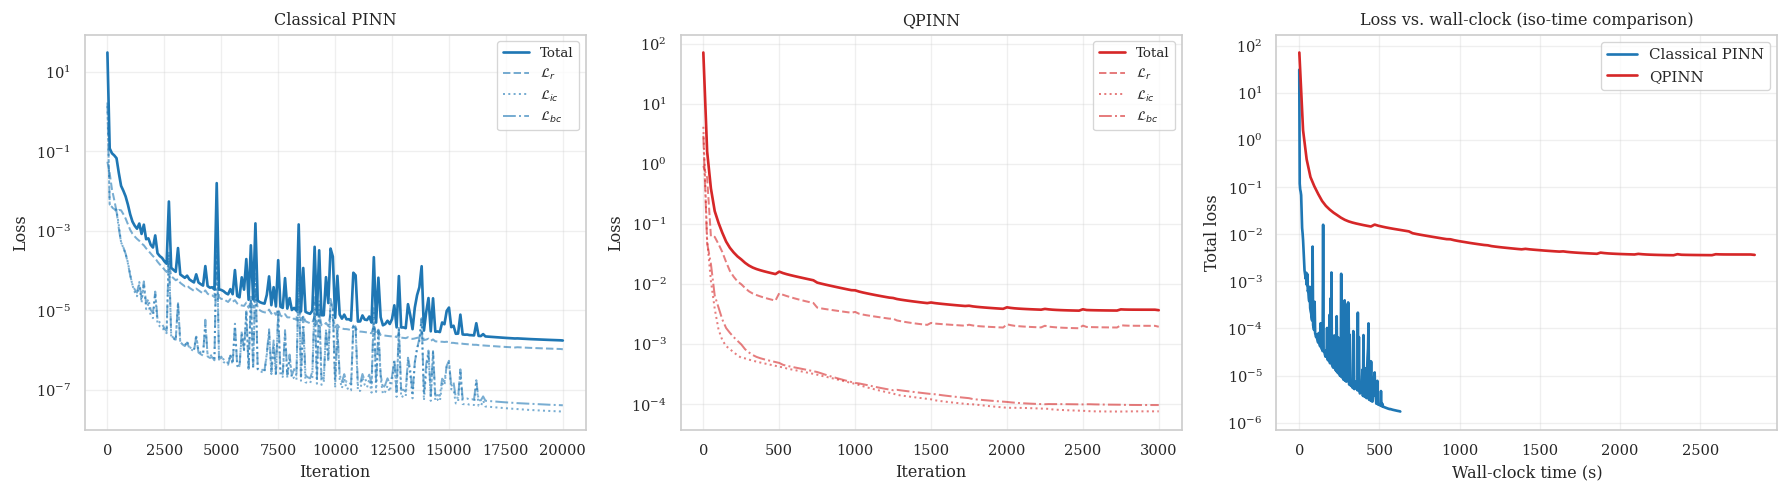

In [26]:
# Cell 14 — loss convergence, PINN vs QPINN
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

for ax, (H, name, c) in zip(
        axes[:2],
        [(hist_pinn["train"], "Classical PINN", "#1f77b4"),
         (hist_qpinn["train"], "QPINN", "#d62728")]):
    ax.semilogy(H["it"], H["loss"], color=c, lw=1.6, label="Total")
    ax.semilogy(H["it"], H["L_r"], "--", color=c, alpha=0.6, label=r"$\mathcal{L}_r$")
    ax.semilogy(H["it"], H["L_ic"], ":", color=c, alpha=0.6, label=r"$\mathcal{L}_{ic}$")
    ax.semilogy(H["it"], H["L_bc"], "-.", color=c, alpha=0.6, label=r"$\mathcal{L}_{bc}$")
    ax.set_title(name)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=8)

ax = axes[2]
ax.semilogy(hist_pinn["train"]["wall"], hist_pinn["train"]["loss"],
            color="#1f77b4", lw=1.6, label="Classical PINN")
ax.semilogy(hist_qpinn["train"]["wall"], hist_qpinn["train"]["loss"],
            color="#d62728", lw=1.6, label="QPINN")
ax.set_xlabel("Wall-clock time (s)")
ax.set_ylabel("Total loss")
ax.set_title("Loss vs. wall-clock (iso-time comparison)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("figs/training_dynamics.png", bbox_inches="tight")
plt.show()

### **Spatiotemporal heatmap**

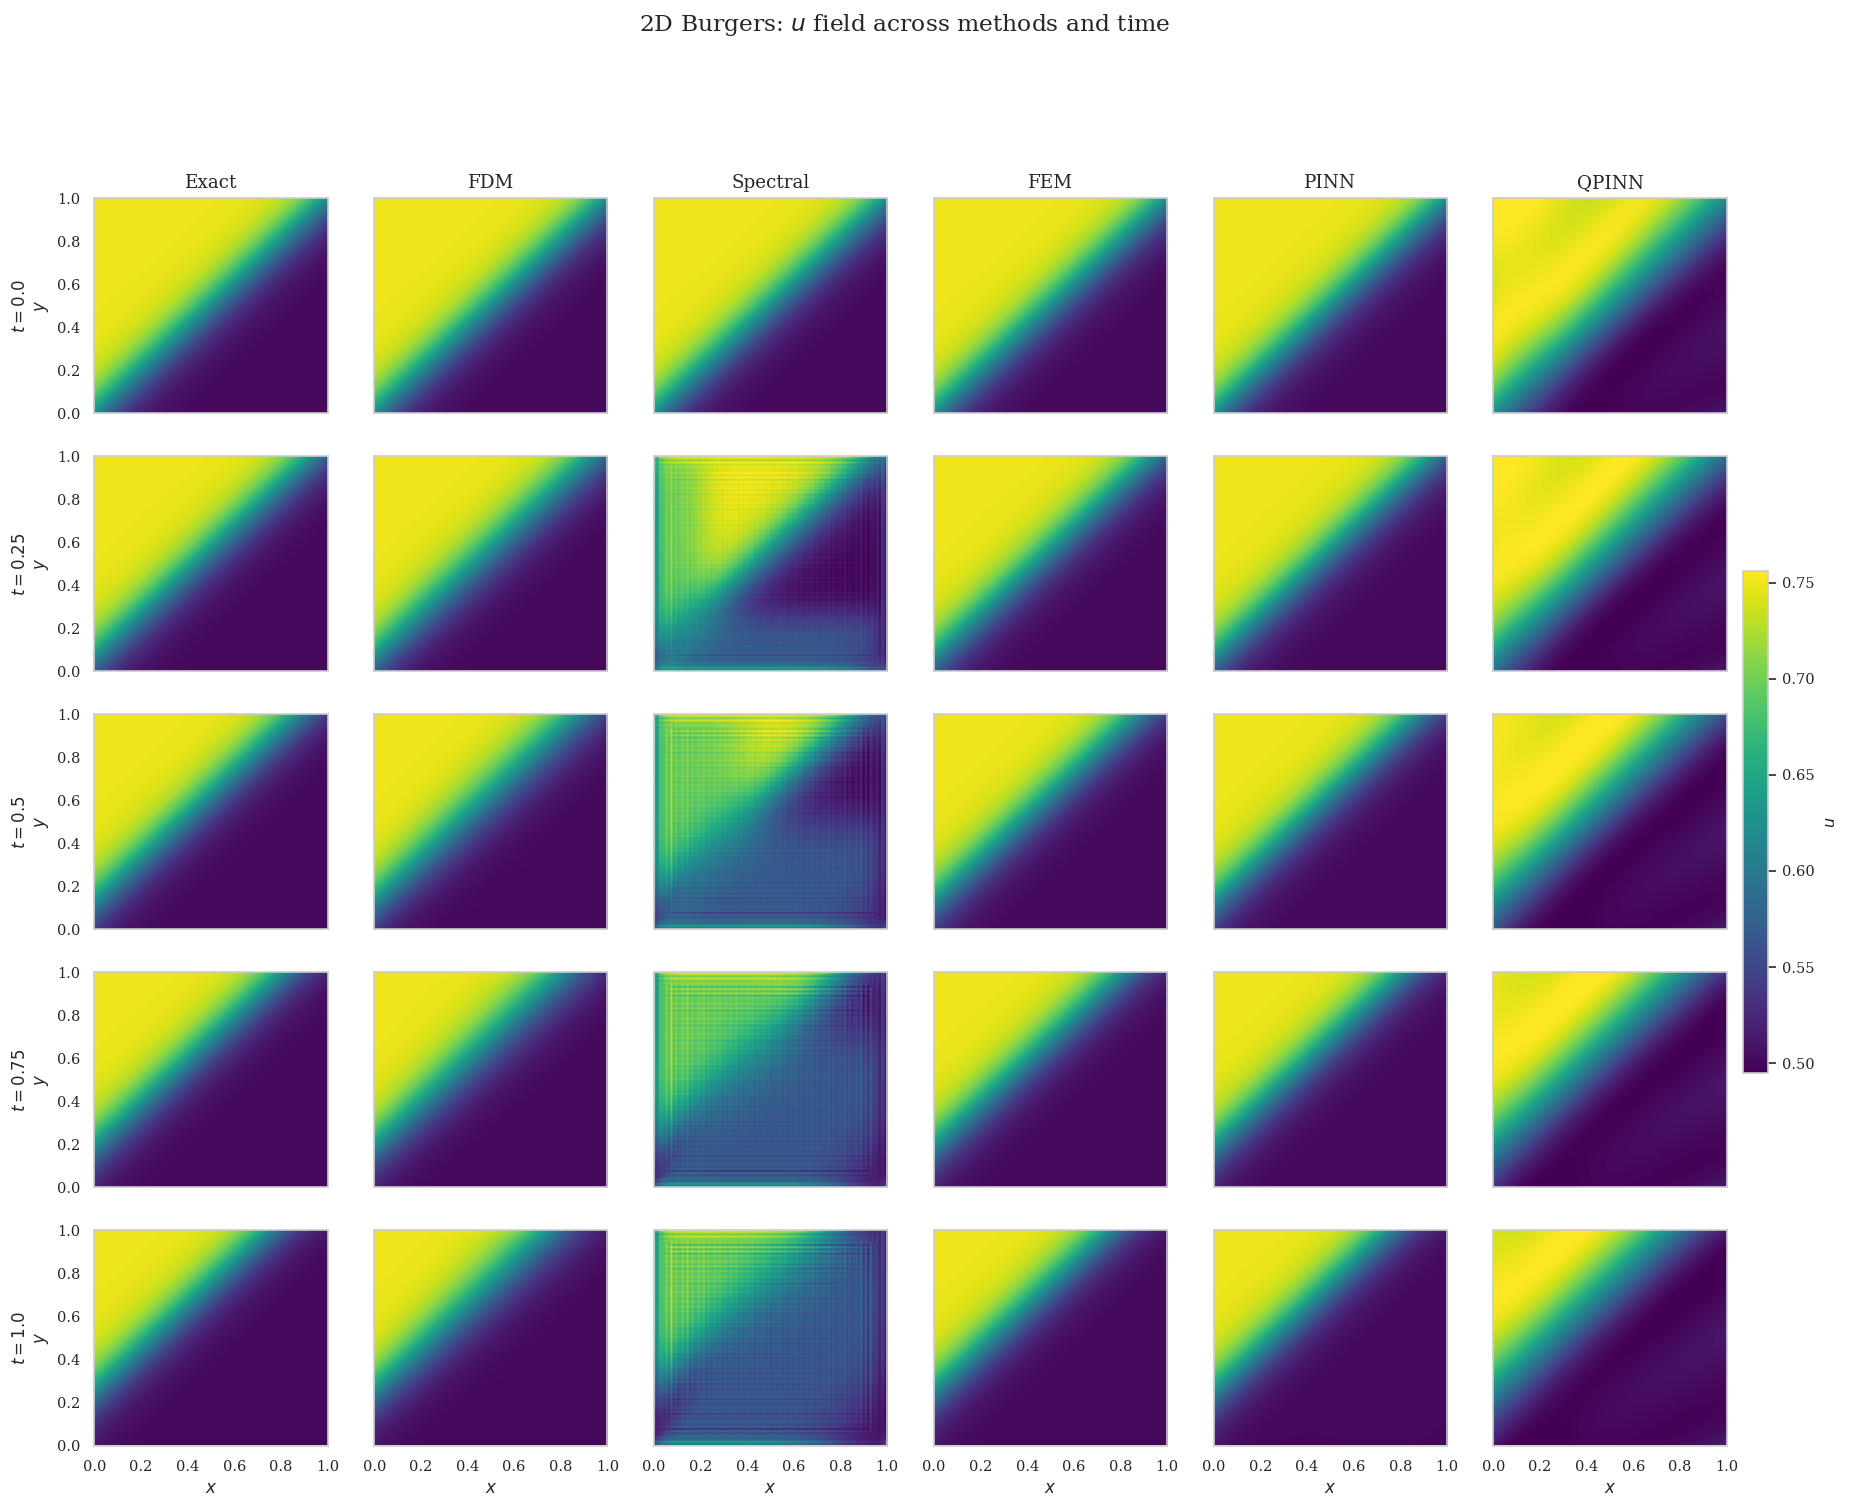

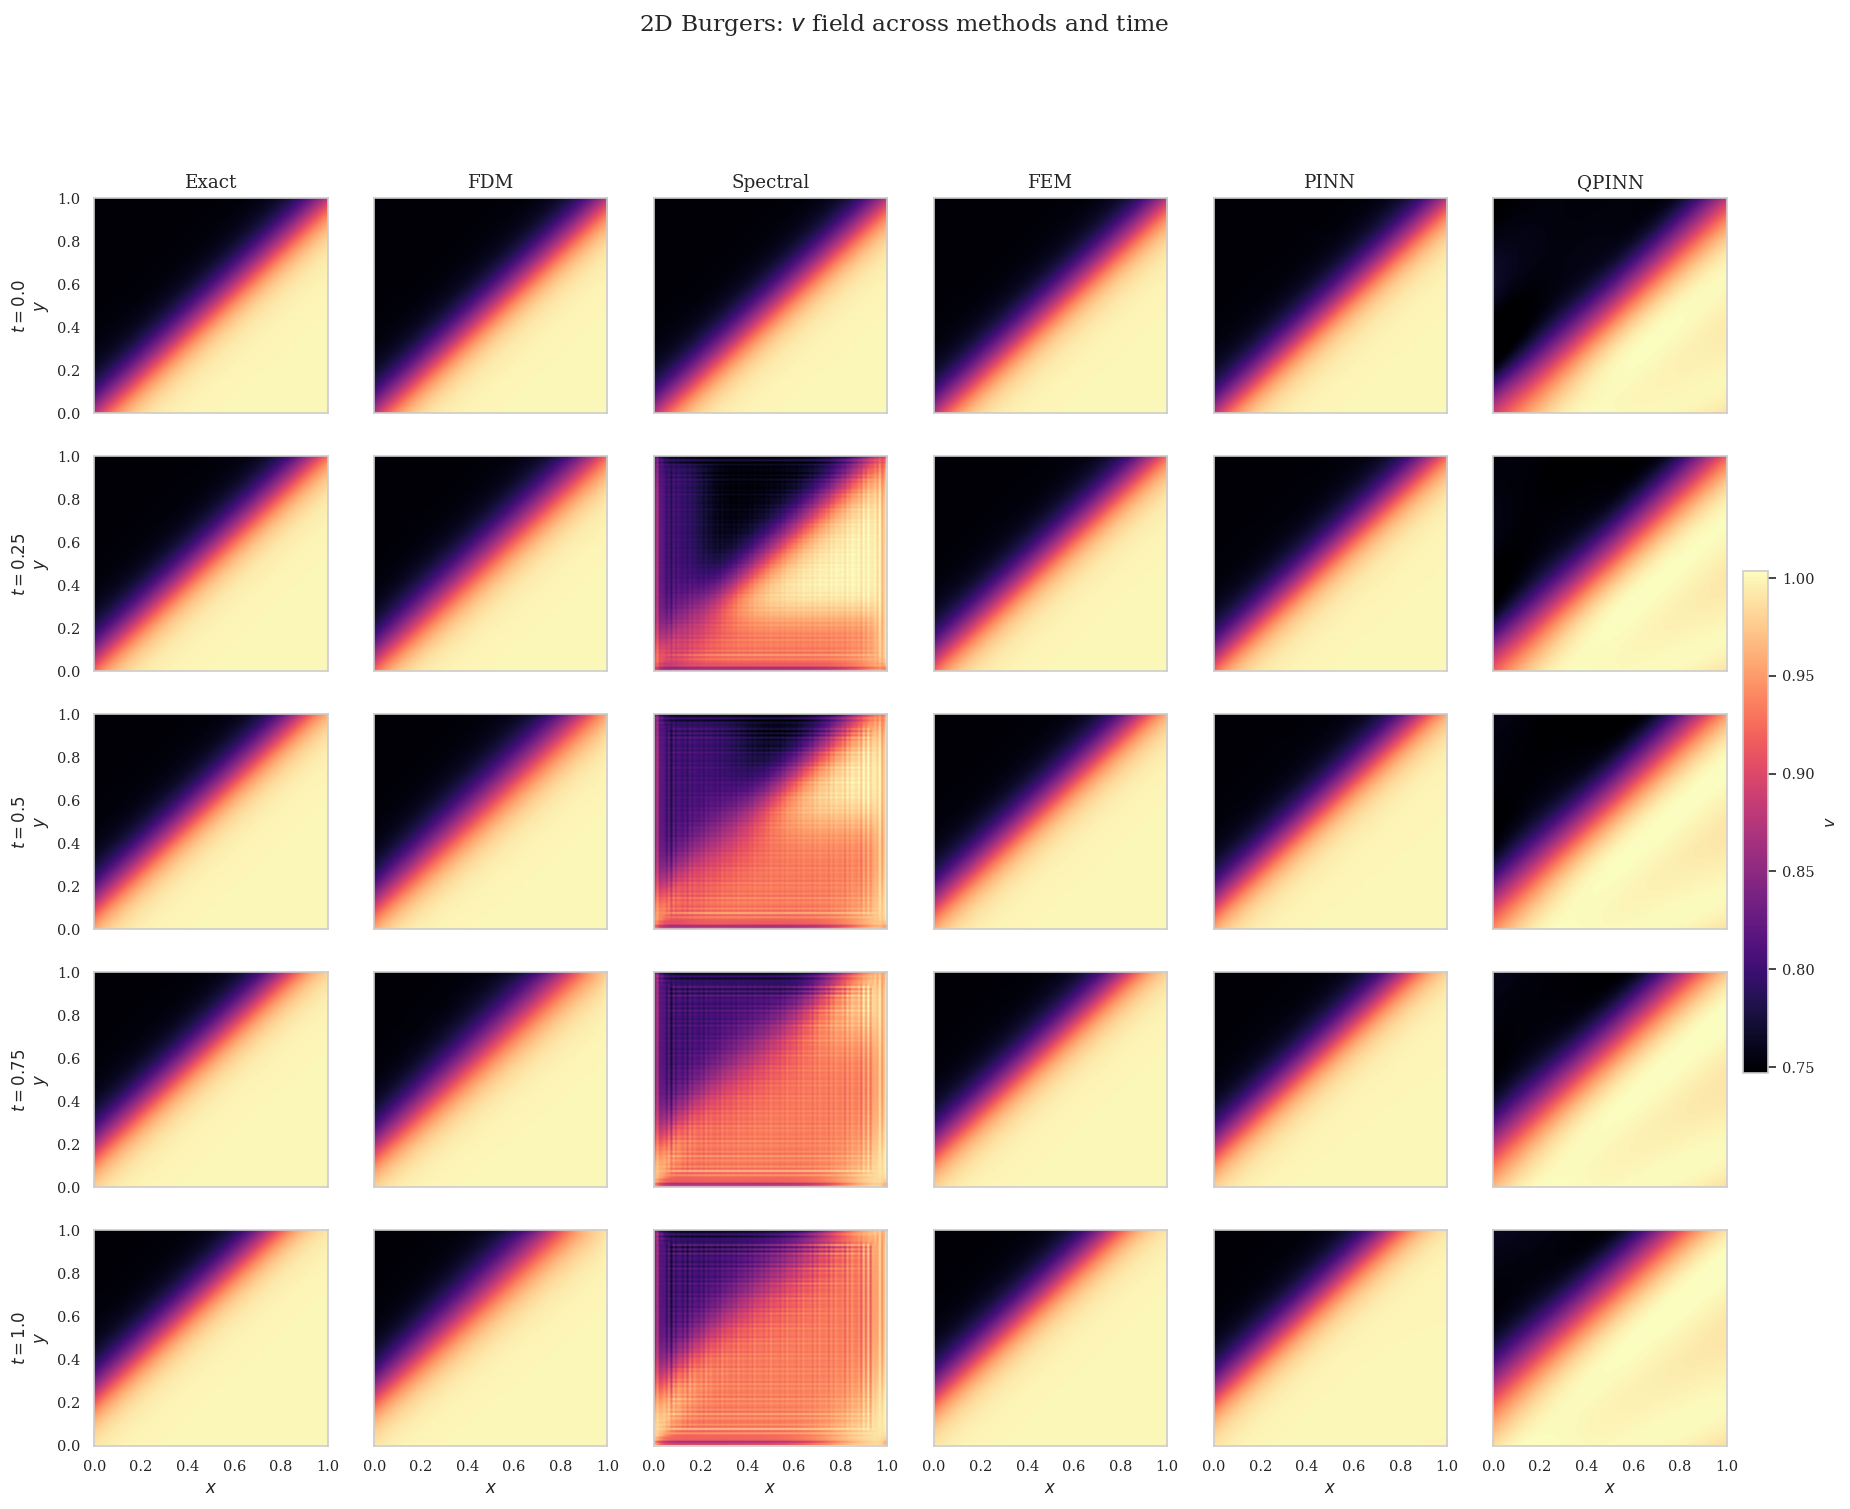

In [27]:
# Cell 15 — heatmap grid: rows = time, cols = method
def heatmap_grid(field="u", cmap="viridis", fname=None):
    methods = ["Exact", "FDM", "Spectral", "FEM", "PINN", "QPINN"]
    k = 0 if field == "u" else 1

    all_vals = np.concatenate(
        [RESULTS[m][t][k].ravel() for m in methods for t in T_EVAL])
    vmin, vmax = np.percentile(all_vals, [0.5, 99.5])

    fig, axes = plt.subplots(len(T_EVAL), len(methods),
                             figsize=(3.0 * len(methods), 2.7 * len(T_EVAL)),
                             sharex=True, sharey=True)

    for i, tt in enumerate(T_EVAL):
        for j, m in enumerate(methods):
            ax = axes[i, j]
            im = ax.imshow(RESULTS[m][tt][k].T, origin="lower",
                           extent=[0, 1, 0, 1], cmap=cmap,
                           vmin=vmin, vmax=vmax, aspect="auto")
            ax.grid(False)
            if i == 0:
                ax.set_title(m, fontsize=11)
            if j == 0:
                ax.set_ylabel(f"$t={tt}$\n$y$", fontsize=10)
            if i == len(T_EVAL) - 1:
                ax.set_xlabel("$x$", fontsize=10)

    fig.colorbar(im, ax=axes, orientation="vertical",
                 fraction=0.015, pad=0.01, label=f"${field}$")
    fig.suptitle(f"2D Burgers: ${field}$ field across methods and time",
                 fontsize=14, y=0.995)
    if fname:
        plt.savefig(fname, bbox_inches="tight")
    plt.show()


heatmap_grid("u", "viridis", "figs/heatmap_u.png")
heatmap_grid("v", "magma", "figs/heatmap_v.png")

### **Error evaluation and absolute error maps**

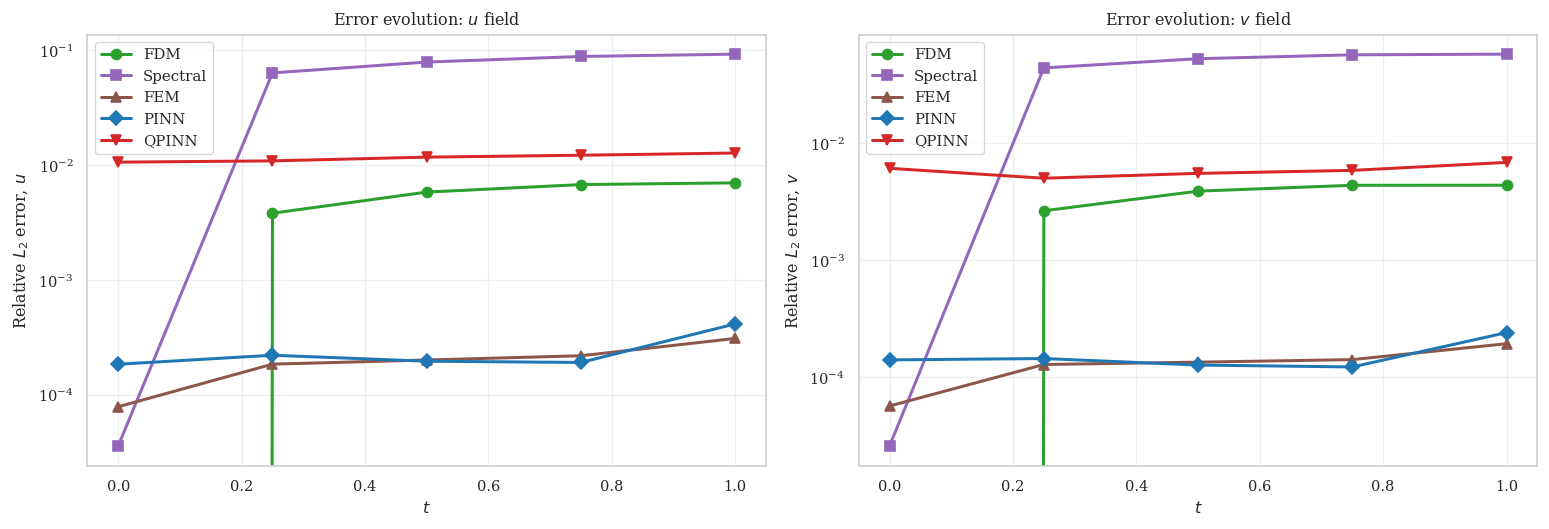

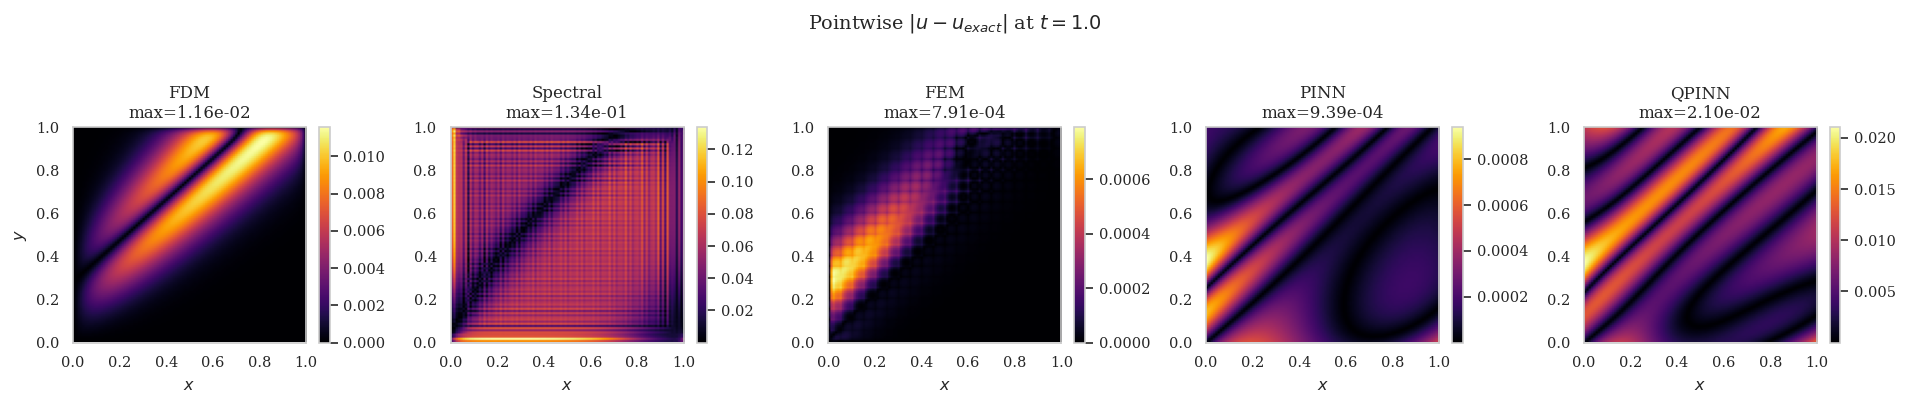

In [28]:
# Cell 16 — error analysis
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
palette = {"FDM": "#2ca02c", "Spectral": "#9467bd",
           "FEM": "#8c564b", "PINN": "#1f77b4", "QPINN": "#d62728"}
markers = {"FDM": "o", "Spectral": "s", "FEM": "^", "PINN": "D", "QPINN": "v"}

for ax, fld in zip(axes, ["u", "v"]):
    for m in ERR:
        ax.semilogy(T_EVAL, ERR[m][fld], marker=markers[m],
                    color=palette[m], lw=1.8, ms=6, label=m)
    ax.set_xlabel("$t$")
    ax.set_ylabel(rf"Relative $L_2$ error, ${fld}$")
    ax.set_title(rf"Error evolution: ${fld}$ field")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("figs/error_evolution.png", bbox_inches="tight")
plt.show()

# Absolute error maps at t = 1.0
methods = ["FDM", "Spectral", "FEM", "PINN", "QPINN"]
fig, axes = plt.subplots(1, len(methods), figsize=(3.2 * len(methods), 3.2))
ue, _ = RESULTS["Exact"][1.0]
for ax, m in zip(axes, methods):
    up, _ = RESULTS[m][1.0]
    im = ax.imshow(np.abs(up - ue).T, origin="lower", extent=[0, 1, 0, 1],
                   cmap="inferno", aspect="auto")
    ax.set_title(f"{m}\nmax={np.abs(up-ue).max():.2e}", fontsize=10)
    ax.grid(False)
    ax.set_xlabel("$x$")
    plt.colorbar(im, ax=ax, fraction=0.046)
axes[0].set_ylabel("$y$")
fig.suptitle(r"Pointwise $|u - u_{exact}|$ at $t=1.0$", y=1.04)
plt.tight_layout()
plt.savefig("figs/error_maps.png", bbox_inches="tight")
plt.show()

## **Interpretability and Activations**

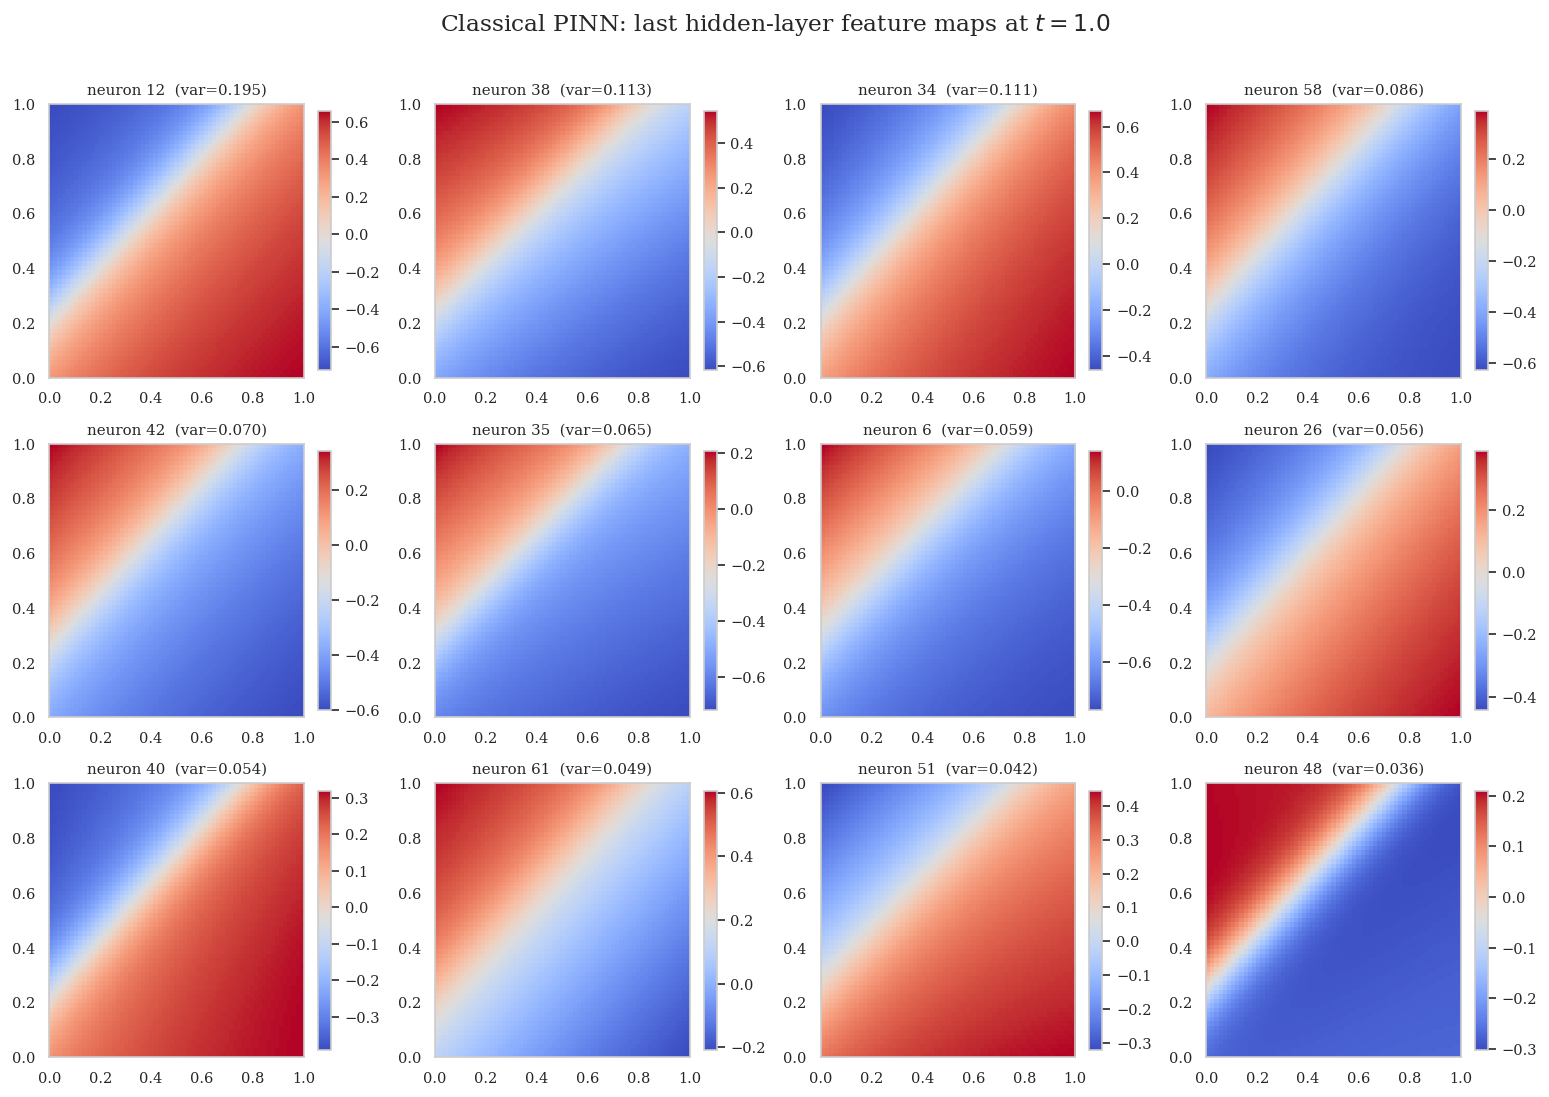

activation effective rank: 2.80 / 64


In [29]:
# Cell 17 — interpretability
# (a) Classical PINN: last hidden-layer activations at t = 1.0
n_vis = 61
lin = torch.linspace(0, 1, n_vis, device=DEVICE)
Xv, Yv = torch.meshgrid(lin, lin, indexing="ij")
inp_vis = torch.stack([Xv.reshape(-1), Yv.reshape(-1),
                       torch.ones(n_vis**2, device=DEVICE)], dim=1)

acts = pinn.hidden_at(inp_vis).cpu().numpy()          # (n_vis^2, width)
var = acts.var(axis=0)
top = np.argsort(var)[::-1][:12]                       # most active neurons

fig, axes = plt.subplots(3, 4, figsize=(13, 9))
for ax, nidx in zip(axes.ravel(), top):
    fm = acts[:, nidx].reshape(n_vis, n_vis)
    im = ax.imshow(fm.T, origin="lower", extent=[0, 1, 0, 1],
                   cmap="coolwarm", aspect="auto")
    ax.set_title(f"neuron {nidx}  (var={var[nidx]:.3f})", fontsize=9)
    ax.grid(False)
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Classical PINN: last hidden-layer feature maps at $t=1.0$",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("figs/pinn_activations.png", bbox_inches="tight")
plt.show()

# Effective rank of the activation matrix: how many independent modes
# the network actually uses to represent the solution.
s = np.linalg.svd(acts - acts.mean(0), compute_uv=False)
p = s / s.sum()
eff_rank = float(np.exp(-(p * np.log(p + 1e-12)).sum()))
print(f"activation effective rank: {eff_rank:.2f} / {acts.shape[1]}")

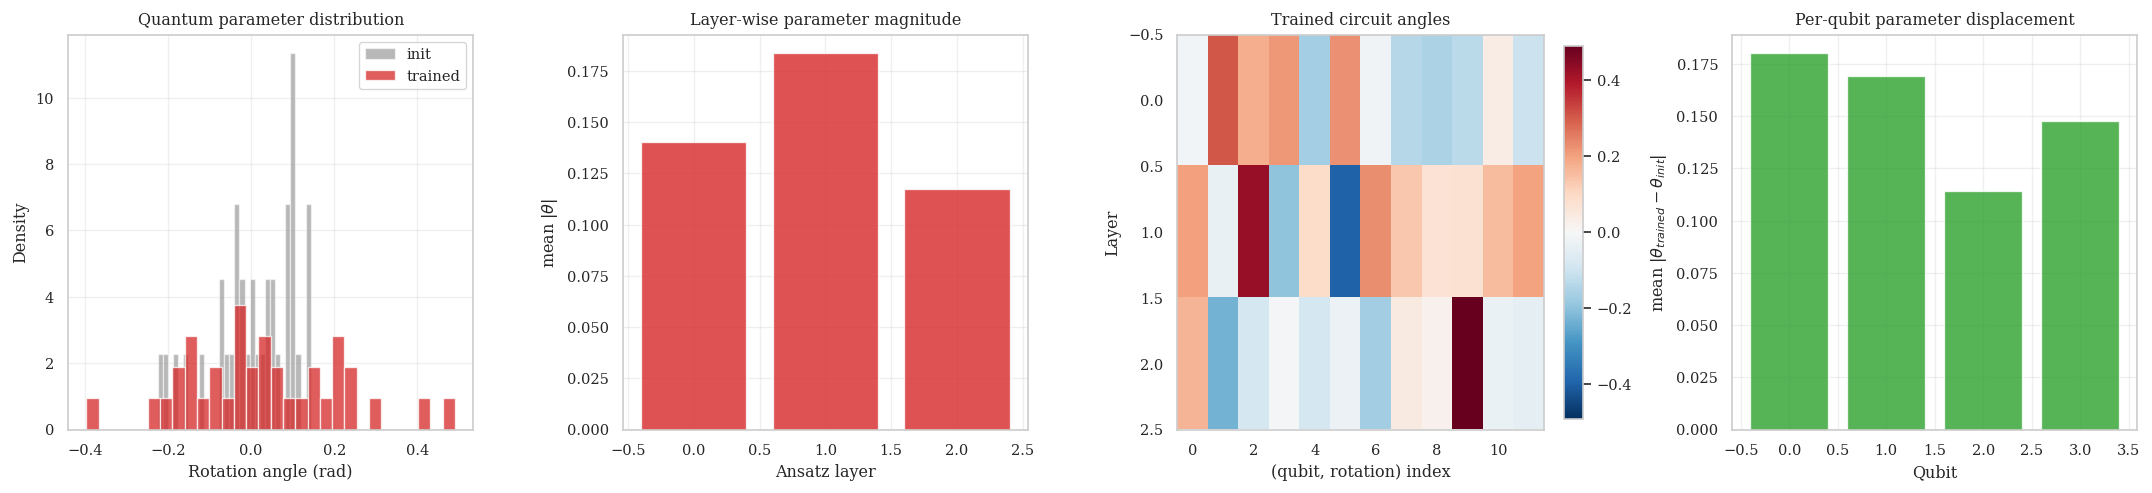

||theta_final - theta_init||_2 = 1.1392


In [30]:
# Cell 17b — QPINN quantum parameter analysis
w_final = qpinn.q_weights.detach().cpu().numpy()       # (L, Q, 3)
w_init = 0.1 * np.random.RandomState(SEED).randn(*w_final.shape)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))

# Angle distribution: initial vs trained
axes[0].hist(w_init.ravel(), bins=30, alpha=0.55, label="init",
             color="#7f7f7f", density=True)
axes[0].hist(w_final.ravel(), bins=30, alpha=0.75, label="trained",
             color="#d62728", density=True)
axes[0].set_xlabel("Rotation angle (rad)")
axes[0].set_ylabel("Density")
axes[0].set_title("Quantum parameter distribution")
axes[0].legend()

# Per-layer angle magnitude
lm = np.abs(w_final).mean(axis=(1, 2))
axes[1].bar(range(len(lm)), lm, color="#d62728", alpha=0.8)
axes[1].set_xlabel("Ansatz layer")
axes[1].set_ylabel(r"mean $|\theta|$")
axes[1].set_title("Layer-wise parameter magnitude")

# Heatmap of trained angles, flattened per layer
im = axes[2].imshow(w_final.reshape(w_final.shape[0], -1),
                    cmap="RdBu_r", aspect="auto",
                    vmin=-np.abs(w_final).max(), vmax=np.abs(w_final).max())
axes[2].set_xlabel("(qubit, rotation) index")
axes[2].set_ylabel("Layer")
axes[2].set_title("Trained circuit angles")
axes[2].grid(False)
plt.colorbar(im, ax=axes[2], fraction=0.046)

# Displacement from initialisation, per qubit
disp = np.abs(w_final - w_init).mean(axis=(0, 2))
axes[3].bar(range(len(disp)), disp, color="#2ca02c", alpha=0.8)
axes[3].set_xlabel("Qubit")
axes[3].set_ylabel(r"mean $|\theta_{trained}-\theta_{init}|$")
axes[3].set_title("Per-qubit parameter displacement")

plt.tight_layout()
plt.savefig("figs/qpinn_params.png", bbox_inches="tight")
plt.show()

print(f"||theta_final - theta_init||_2 = "
      f"{np.linalg.norm(w_final - w_init):.4f}")

### **Summary Benchmark**

In [31]:
# Cell 18 — consolidated benchmark table
rows = []
wall_map = {"FDM": wall_fdm, "Spectral": wall_sp, "FEM": wall_fem,
            "PINN": hist_pinn["train"]["wall"][-1],
            "QPINN": hist_qpinn["train"]["wall"][-1]}
dof_map = {"FDM": 101 * 101 * 2, "Spectral": 128 * 128 * 2,
           "FEM": 81 * 81 * 2,
           "PINN": sum(p.numel() for p in pinn.parameters()),
           "QPINN": sum(p.numel() for p in qpinn.parameters())}

for m in ["FDM", "Spectral", "FEM", "PINN", "QPINN"]:
    rows.append({
        "Method": m,
        "rel L2 (u, t=1)": f"{ERR[m]['u'][-1]:.3e}",
        "rel L2 (v, t=1)": f"{ERR[m]['v'][-1]:.3e}",
        "mean rel L2 (u)": f"{np.mean(ERR[m]['u']):.3e}",
        "DOF / params": dof_map[m],
        "wall (s)": f"{wall_map[m]:.1f}",
    })

summary = pd.DataFrame(rows).set_index("Method")
print(summary.to_string())
summary.to_csv("figs/benchmark_summary.csv")

         rel L2 (u, t=1) rel L2 (v, t=1) mean rel L2 (u)  DOF / params wall (s)
Method                                                                         
FDM            7.002e-03       4.368e-03       4.679e-03         20402      1.5
Spectral       9.238e-02       5.763e-02       6.457e-02         32768    129.1
FEM            3.096e-04       1.931e-04       1.986e-04         13122      1.1
PINN           4.146e-04       2.402e-04       2.416e-04         17026    630.2
QPINN          1.273e-02       6.845e-03       1.162e-02          2634   2839.8


In [32]:
from google.colab import drive
drive.mount('/content/drive')
!cp -r figs runs /content/drive/MyDrive/qapinn_2d_burgers/

Mounted at /content/drive
cp: target '/content/drive/MyDrive/qapinn_2d_burgers/' is not a directory
